In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/scaled-train-final-2/scaled_train_labeled_except_label_final.csv
/kaggle/input/scaled-dataset-train/scaled_dataset_train.csv
/kaggle/input/scaled-train-labeled-except-label/scaled_dataset_train_labeled_except_label.csv


In [2]:
!pip install ReliefF


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for ReliefF: filename=ReliefF-0.1.2-py3-none-any.whl size=6303 sha256=f958746647537584d9af98c0e2855ae09a0fc9df07fc400f8c9345635f3b15eb
  Stored in directory: /root/.cache/pip/wheels/b3/78/52/e9c928cdcbb49851a3efda770b1b424f9a482a154399159246
Successfully built ReliefF


Saved final dataset as relieff_selected_25.csv
Shape of new dataset: (559396, 26)


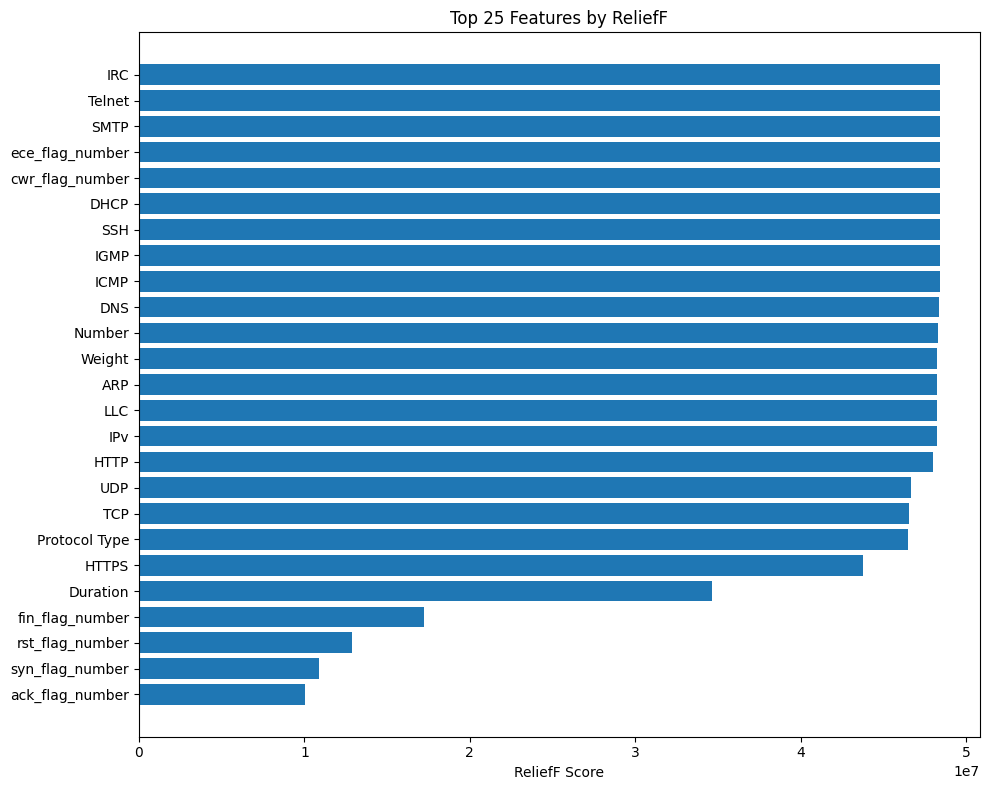

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from ReliefF import ReliefF

# Step 1: Load the scaled dataset
df = pd.read_csv('/kaggle/input/scaled-train-final-2/scaled_train_labeled_except_label_final.csv')

# Step 2: Separate features and target
X = df.drop(columns=['Label'])
y = df['Label']

# Step 3: Initialize and fit ReliefF
selector = ReliefF(n_neighbors=100)
selector.fit(X.values, y.values)

# Step 4: Get feature scores and names
scores = selector.feature_scores
feature_names = X.columns

# Step 5: Create DataFrame of feature importances
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Score': scores
}).sort_values(by='Score', ascending=False)

# Step 6: Select top 35 features only
top_features = importance_df['Feature'].values[:25]
X_selected = X[top_features]

# Step 7: Combine selected features with label using .loc to avoid warning
selected_df = pd.DataFrame(X_selected, columns=top_features)
selected_df.loc[:, 'Label'] = y  # Clean way to add label

# Step 8: Save final reduced dataset
selected_df.to_csv('relieff_selected_25.csv', index=False)
print("Saved final dataset as relieff_selected_25.csv")
print("Shape of new dataset:", selected_df.shape)

# Step 9: Plot top 35 features
plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'].values[:25][::-1], importance_df['Score'].values[:25][::-1])
plt.xlabel('ReliefF Score')
plt.title('Top 25 Features by ReliefF')
plt.tight_layout()
plt.show()
